# Pronóstico de Compromisos de Crédito — Tarjeta Plus
## Gerencia de Metodologías de Riesgo de Mercado de Capitales
### Marzo 2026

Los compromisos de crédito representan obligaciones futuras de desembolso que una entidad bancaria ha preaprobado a sus clientes. Gestionar adecuadamente estos compromisos es una necesidad operativa concreta, ya que el banco debe garantizar la disponibilidad de fondos para cubrir los desembolsos que los clientes decidan realizar sobre sus cupos aprobados. Anticipar su comportamiento es, por tanto, un elemento central de la gestión del riesgo de liquidez.

Este análisis construye un modelo de pronóstico del porcentaje mensual de utilización del cupo de la Tarjeta Plus, con horizonte de tres meses. Para ello, se comparan múltiples arquitecturas de series de tiempo, se selecciona la más adecuada con base en métricas de desempeño, y se propone un esquema de backtesting orientado a validar su robustez en un entorno productivo. El conjunto de datos corresponde al comportamiento mensual de los Compromisos de Crédito de la Tarjeta Plus — preaprobados o futuros desembolsos — registrado como porcentaje de utilización del cupo disponible.

El análisis está organizado en las siguientes secciones:
- Carga y exploración de datos
- Análisis de estacionariedad
- Torneo de modelos y selección
- Pronóstico a 3 meses
- Backtesting
- Conclusiones

## Exploración de datos

In [65]:
#Importamos librerias a utilizar segun lo requerido en el proyecto
import pandas as pd
import matplotlib.pyplot as plt

In [66]:
df = pd.read_excel('TarjetaPlus.xlsx') #Leemos el archivo de excel con los datos a analizar
df.head()

,Fecha,Porcentaje de utilización del cupo
0,2019-05-31,0.105176
1,2019-06-30,0.086477
2,2019-07-31,0.104061
3,2019-08-31,0.089117
4,2019-09-30,0.100496


El dataset comprende dos columnas: fecha y porcentaje de utilización del cupo.

In [67]:
df.isnull().sum()

Fecha                                 0
Porcentaje de utilización del cupo    0
dtype: int64

In [68]:
print(df.dtypes)
print(df['Fecha'].is_monotonic_increasing)

Fecha                                 datetime64[ns]
Porcentaje de utilización del cupo           float64
dtype: object
True


No hay valores nulos por tratar y el formato de fechas leído por pandas si es el correcto.

Con los datos completos, se analiza la evolución temporal de la serie.

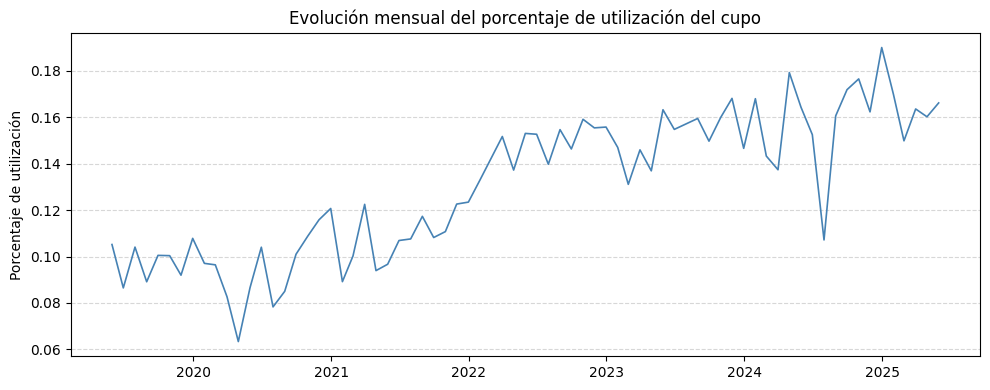

In [69]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['Fecha'], df['Porcentaje de utilización del cupo'], color='steelblue', linewidth=1.2)
ax.set_title('Evolución mensual del porcentaje de utilización del cupo')
ax.set_ylabel('Porcentaje de utilización')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Con los datos completos, se analiza la distribución de la serie mediante un boxplot 
para identificar valores atípicos que deban tratarse antes del modelado.

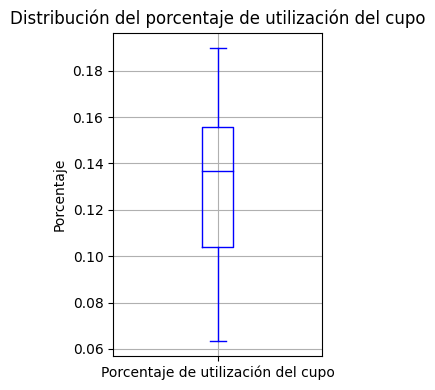

In [70]:
df.boxplot(column='Porcentaje de utilización del cupo', 
           figsize=(3, 4),
           color='blue')
plt.title('Distribución del porcentaje de utilización del cupo')
plt.ylabel('Porcentaje')
plt.tight_layout()
plt.show()

El boxplot revela que en condiciones normales el uso del cupo es predecible 
y estable — la mediana de 13.5% indica que la mitad del tiempo los clientes 
utilizan menos de esa proporción de su cupo disponible. La estrechez de la 
caja confirma baja volatilidad estructural, una señal favorable para el 
pronóstico. El outlier inferior corresponde a un evento económico externo 
puntual que se conserva en el análisis al no representar un error en los datos.

In [71]:
df['Porcentaje de utilización del cupo'].describe()

count    71.000000
mean      0.130271
std       0.030590
min       0.063352
25%       0.104035
50%       0.136924
75%       0.155608
max       0.190050
Name: Porcentaje de utilización del cupo, dtype: float64

In [72]:
df[df['Fecha'].dt.year == 2024].nsmallest(1, 'Porcentaje de utilización del cupo')

,Fecha,Porcentaje de utilización del cupo
60,2024-07-31,0.107143


El dataset comprende 71 observaciones. La serie oscila entre 6.3% y 19%, 
con una media de 13% y desviación estándar baja (3%), confirmando el 
comportamiento estable identificado en el boxplot. Se identifican dos caídas 
atípicas — abril 2020 y julio 2024 — probablemente asociadas a factores 
económicos externos. La tendencia creciente sostenida entre 2019 y 2025 
anticipa la ausencia de estacionariedad.

## Estacionariedad

La estacionariedad es un requisito fundamental para el modelado de series de tiempo. 
Se aplica la prueba Augmented Dickey-Fuller (ADF) para verificar formalmente si la 
serie presenta raíz unitaria.

In [75]:
from statsmodels.tsa.stattools import adfuller

In [76]:
result = adfuller(df['Porcentaje de utilización del cupo'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')

ADF Statistic: -1.0610
p-value: 0.7304


La prueba ADF evalúa la hipótesis nula de que la serie tiene raíz unitaria, 
es decir, que no es estacionaria. Un p-value mayor a 0.05 indica que no hay 
evidencia suficiente para rechazar dicha hipótesis. Con un p-value de 0.73, 
la serie no es estacionaria, resultado consistente con la tendencia creciente 
sostenida observada en el análisis exploratorio. Los modelos seleccionados 
para el torneo manejan esta característica internamente mediante diferenciación.

Dado el resultado concluyente del ADF, no se requiere una prueba complementaria.

## Torneo de modelos y selección

Se comparan tres arquitecturas de series de tiempo — ARIMA, SARIMA y Holt-Winters — 
seleccionadas por su idoneidad para series cortas con tendencia. El modelo ganador 
se selecciona con base en RMSE, MAE y MAPE. 

La división no sigue una proporción 
estándar sino el horizonte de pronóstico requerido: los últimos 3 meses como prueba, 
de forma que la evaluación refleje exactamente el escenario productivo al que está destinado.

In [77]:
# Dividimos los datos en entrenamiento y prueba
train = df.iloc[:-3]
test = df.iloc[-3:]

print(f'Train: {len(train)} observaciones')
print(f'Test: {len(test)} observaciones')

Train: 68 observaciones
Test: 3 observaciones


ARIMA(1,1,1) se entrena con parámetros de referencia estándar: un término autorregresivo, una diferenciación de primer orden y un término de media móvil. La diferenciación se justifica porque la serie original presenta no estacionariedad (ADF p=0.70). La diferenciación de primer orden se adopta como transformación estándar para corregir la no estacionariedad identificada en la serie original y permitir el ajuste de ARIMA..

In [78]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Entrenamos ARIMA(1,1,1) — diferenciación integrada maneja la no estacionariedad
modelo_arima = SARIMAX(train['Porcentaje de utilización del cupo'], 
                       order=(1, 1, 1)).fit(disp=False)

pred_arima = modelo_arima.forecast(3)
print(pred_arima.values)

[0.16175306 0.1630927  0.16324353]


El modelo proyecta una utilización del cupo de aproximadamente 16.2% para los 
próximos tres meses, con una leve tendencia al alza que se estabiliza rápidamente. 
Este comportamiento es típico de ARIMA con una sola diferenciación, que tiende 
a aplanarse en horizontes cortos.

Holt-Winters con tendencia aditiva modela explícitamente el componente de tendencia 
de la serie, asignando mayor peso a las observaciones recientes. Se usa tendencia 
aditiva dado que la serie muestra un crecimiento lineal sostenido, consistente con 
lo observado en el análisis exploratorio.

In [79]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Entrenamos Holt-Winters con tendencia aditiva
modelo_hw = ExponentialSmoothing(train['Porcentaje de utilización del cupo'],
                                  trend='add').fit()

pred_hw = modelo_hw.forecast(3)
print(pred_hw.values)

[0.16808809 0.16917451 0.17026092]


El modelo proyecta una utilización del cupo de aproximadamente 16.8% para el primer 
mes, con una tendencia creciente sostenida que alcanza 17% al tercer mes. A diferencia 
de ARIMA, Holt-Winters mantiene la tendencia activa en el horizonte de pronóstico, 
lo cual es consistente con el comportamiento histórico de la serie.

SARIMA extiende ARIMA incorporando un componente estacional. Se incluye en el torneo 
para verificar si existe algún patrón anual sutil no evidente en el análisis exploratorio. 
Se usa un período estacional de 12 meses sin diferenciación estacional, dado que no 
hay evidencia fuerte de estacionalidad en la serie.

In [80]:
# Entrenamos SARIMA(1,1,1)(1,0,0,12) — captura posible estacionalidad anual
modelo_sarima = SARIMAX(train['Porcentaje de utilización del cupo'],
                        order=(1, 1, 1),
                        seasonal_order=(1, 0, 0, 12)).fit(disp=False)

pred_sarima = modelo_sarima.forecast(3)
print(pred_sarima.values)

[0.16109166 0.16396081 0.16359325]


El modelo proyecta una utilización del cupo de aproximadamente 16.1% para el primer 
mes, con una leve recuperación hacia 16.4% en el segundo y una ligera caída al tercer 
mes. La variación entre períodos es mínima, sugiriendo que el componente estacional 
no aporta información significativa adicional respecto a ARIMA.

Se evalúan los tres modelos sobre el conjunto de prueba utilizando RMSE, MAE y MAPE. 
El RMSE penaliza errores grandes, el MAE refleja el error promedio absoluto, y el MAPE 
expresa el error como porcentaje del valor real, facilitando la interpretación del 
tamaño del error en términos del negocio.

In [84]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

real = test['Porcentaje de utilización del cupo'].values

def mape(real, pred):
    return np.mean(np.abs((real - pred) / real)) * 100

resultados = {
    'Modelo':   ['ARIMA', 'Holt-Winters', 'SARIMA'],
    'RMSE (%)': [np.sqrt(mean_squared_error(real, pred_arima)) * 100,
                 np.sqrt(mean_squared_error(real, pred_hw)) * 100,
                 np.sqrt(mean_squared_error(real, pred_sarima)) * 100],
    'MAE (%)':  [mean_absolute_error(real, pred_arima) * 100,
                 mean_absolute_error(real, pred_hw) * 100,
                 mean_absolute_error(real, pred_sarima) * 100],
    'MAPE (%)': [mape(real, pred_arima),
                 mape(real, pred_hw),
                 mape(real, pred_sarima)]
}

df_resultados = pd.DataFrame(resultados).set_index('Modelo').round(4)
df_resultados

,RMSE (%),MAE (%),MAPE (%)
Modelo,,,
ARIMA,0.2598,0.2548,1.5604
Holt-Winters,0.6250,0.5847,3.5998
SARIMA,0.2996,0.2941,1.8056


No se incorporaron variables exógenas debido al horizonte corto de pronóstico y al tamaño limitado de la muestra, priorizando una arquitectura univariada para evitar sobreajuste.

ARIMA presenta el mejor desempeño en las tres métricas evaluadas, con un MAPE de 1.56%, nivel de error relativo sólido para una serie financiera de esta escala. 

Se selecciona MAPE como métrica principal por su capacidad de expresar el error en términos porcentuales, facilitando su interpretación en contextos de riesgo donde la magnitud del desvío debe evaluarse proporcionalmente al valor observado. SARIMA ocupa el segundo lugar, pero su mayor complejidad no se justifica frente a la mejora marginal obtenida.

Holt-Winters se descarta al presentar errores superiores en todas las métricas, lo que sugiere que una estructura de tendencia explícita no captura adecuadamente la dinámica observada. En consecuencia, se selecciona ARIMA(1,1,1) como modelo final por su balance entre precisión, parsimonia y robustez.



## Backtesting

La evaluación train/test realizada mide el desempeño del modelo en un único corte temporal: se entrena con el histórico disponible y se compara el pronóstico de tres meses contra los valores observados. Esto permite comparar arquitecturas, pero no evalúa estabilidad temporal.

Para complementar esta validación se implementa backtesting tipo walk-forward: el modelo se reentrena en múltiples cortes secuenciales, generando pronósticos de tres meses y midiendo el error en cada iteración. Así se evalúa consistencia del desempeño bajo distintas ventanas históricas.

In [90]:
serie = df['Porcentaje de utilización del cupo']

resultados_bt = []

# Empezamos en mes 60 para dejar suficiente historia
for i in range(60, len(serie) - 3):

    train_bt = serie[:i]
    test_bt = serie[i:i+3]

    modelo_bt = SARIMAX(train_bt,
                        order=(1, 1, 1)).fit(disp=False)

    pred_bt = modelo_bt.forecast(3)

    mae = mean_absolute_error(test_bt, pred_bt)
    rmse = np.sqrt(mean_squared_error(test_bt, pred_bt))
    mape = np.mean(np.abs((test_bt - pred_bt) / test_bt)) * 100

    resultados_bt.append({
        'cutoff': i,
        'MAE': mae*100,
        'RMSE': rmse*100,
        'MAPE': mape
    })

backtest_df = pd.DataFrame(resultados_bt)
print("iteraciones: ",len(backtest_df))
print(backtest_df.mean())

iteraciones:  8
cutoff    63.500000
MAE        1.915829
RMSE       2.191824
MAPE      11.964392
dtype: float64


El ejercicio se realizó sobre múltiples ventanas móviles históricas.

El backtesting muestra un MAE promedio de 0.019 y un RMSE de 0.022, sin evidencia de errores extremos relevantes. El MAPE promedio de 11.96% refleja un desempeño estable al evaluar múltiples ventanas históricas, superior en exigencia frente al corte puntual train/test.

La diferencia frente al error del test final confirma que el desempeño depende del contexto temporal, lo que justifica monitoreo periódico en producción.

# Conclusiones


El comportamiento histórico del porcentaje de utilización del cupo muestra una tendencia creciente moderada, sin evidencia de estacionalidad relevante y con baja volatilidad estructural. Bajo este contexto, ARIMA(1,1,1) ofrece el mejor balance entre precisión y parsimonia, superando a las demás arquitecturas tanto en el corte de prueba como en backtesting.

El pronóstico a tres meses sugiere estabilización alrededor de 16%, sin señales de cambios abruptos en el corto plazo. Desde la perspectiva de riesgo, esto indica un comportamiento predecible de los compromisos futuros y refuerza la utilidad de un monitoreo periódico para detectar oportunamente desviaciones ante cambios en el entorno económico.